# NeuroDyads GSoC 2026: Brain-to-Brain Decoder Pre-Task

**Name:** Vennela Varshini Anasoori  
**Email:** vennelavarshini07@gmail.com  
**GitHub:** vennelavarshini18  


## Overview

In this notebook I work with two raw EEG recordings taken simultaneously from
two people having a conversation, one Speaker and one Listener.

The goal is to learn patterns of joint neural activity between their brains
using CEBRA. I combine both recordings into a single T x 128 joint matrix and
train the model to find structure across two emotional conditions: positive
affect and negative affect.

## Steps

**Part 1:** Load both EDF files, remove VREF channel, segment using DIN1
markers, run ICA and reject artifact components based on time series inspection.

**Part 2:** Build joint matrix, z-normalize, train CEBRA with affect labels,
run shuffled label control. Results: KNN accuracy 1.0 vs 0.50, GOF 0.8172 vs 0.0.

**Part 3:** Interpret the 3D embedding geometry and what the control result means.

**Part 4:** Identify the single most specific limitation of this analysis.


## Dataset

- Speaker.edf and Listener.edf, 64 channel EGI HydroCel nets, 250 Hz  
- Positive affect: marker 1 to marker 2, approximately 148 seconds  
- Negative affect: marker 3 to end of file, approximately 154 seconds

In [4]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.preprocessing import ICA
import warnings

# suppress warnings
warnings.filterwarnings("ignore")
mne.set_log_level("WARNING")

print("MNE version:", mne.__version__)
print("Libraries loaded successfully.")

MNE version: 1.11.0
Libraries loaded successfully.


In [5]:
# load EEG data for both participants
raw_A = mne.io.read_raw_edf("Speaker.edf", preload=True)
raw_B = mne.io.read_raw_edf("Listener.edf", preload=True)

print("Participant A info:")
print(raw_A.info)

print("\nNumber of channels:", len(raw_A.ch_names))
print("Recording duration:", round(raw_A.times[-1],1), "sec")
print("Sampling rate:", raw_A.info["sfreq"], "Hz")

print("\nParticipant B info:")
print(raw_B.info)

# extract event markers
events_A, event_id_A = mne.events_from_annotations(raw_A)
events_B, event_id_B = mne.events_from_annotations(raw_B)

print("\nEvents for Participant A:")
print(event_id_A)
print(events_A)

print("\nEvents for Participant B:")
print(event_id_B)
print(events_B)

Participant A info:
<Info | 8 non-empty values
 bads: []
 ch_names: EEG 1, EEG 2, EEG 3, EEG 4, EEG 5, EEG 6, EEG 7, EEG 8, EEG 9, ...
 chs: 65 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: 2023-09-12 03:57:01 UTC
 nchan: 65
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: NT#10-speak, sex: 0, last_name: X>
>

Number of channels: 65
Recording duration: 303.0 sec
Sampling rate: 250.0 Hz

Participant B info:
<Info | 8 non-empty values
 bads: []
 ch_names: EEG 1, EEG 2, EEG 3, EEG 4, EEG 5, EEG 6, EEG 7, EEG 8, EEG 9, ...
 chs: 65 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: 2023-08-26 09:12:54 UTC
 nchan: 65
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: NT#9-Listen, sex: 0, last_name: X>
>

Events for Participant A:
{'DIN1': 1, 'VBeg': 2, 'VEnd': 3}
[[  178     0     2]
 [  197     0     1]
 [37140     0     1]
 [37209     0     1]
 [75607     0     3]]

Events for Participant B:
{

# Part 1 : Preprocessing

In [6]:
# remove VREF channel (reference electrode)

print("Channels before:", len(raw_A.ch_names))
print("Channel names:", raw_A.ch_names)

# find possible VREF channel
vref = [ch for ch in raw_A.ch_names if "VREF" in ch.upper() or ch == "E65"]
print("Possible VREF channel:", vref)

# drop it from both recordings
if vref:
    raw_A.drop_channels(vref)
    raw_B.drop_channels([ch for ch in raw_B.ch_names if "VREF" in ch.upper() or ch == "E65"])

print("Channels after:", len(raw_A.ch_names))  # should be 64

Channels before: 65
Channel names: ['EEG 1', 'EEG 2', 'EEG 3', 'EEG 4', 'EEG 5', 'EEG 6', 'EEG 7', 'EEG 8', 'EEG 9', 'EEG 10', 'EEG 11', 'EEG 12', 'EEG 13', 'EEG 14', 'EEG 15', 'EEG 16', 'EEG 17', 'EEG 18', 'EEG 19', 'EEG 20', 'EEG 21', 'EEG 22', 'EEG 23', 'EEG 24', 'EEG 25', 'EEG 26', 'EEG 27', 'EEG 28', 'EEG 29', 'EEG 30', 'EEG 31', 'EEG 32', 'EEG 33', 'EEG 34', 'EEG 35', 'EEG 36', 'EEG 37', 'EEG 38', 'EEG 39', 'EEG 40', 'EEG 41', 'EEG 42', 'EEG 43', 'EEG 44', 'EEG 45', 'EEG 46', 'EEG 47', 'EEG 48', 'EEG 49', 'EEG 50', 'EEG 51', 'EEG 52', 'EEG 53', 'EEG 54', 'EEG 55', 'EEG 56', 'EEG 57', 'EEG 58', 'EEG 59', 'EEG 60', 'EEG 61', 'EEG 62', 'EEG 63', 'EEG 64', 'EEG VREF']
Possible VREF channel: ['EEG VREF']
Channels after: 64


In [28]:
print("Participant A events:")
print(events_A)
print("\nEvent IDs:", event_id_A)
print("\nTotal duration:", round(raw_A.times[-1], 1), "sec")

print("\nAll marker times for Participant A:")
sf = raw_A.info["sfreq"]
for i, ev in enumerate(events_A):
    t = ev[0] / sf
    print(f"  row {i}: sample {ev[0]}  time {t:.2f}s  type code {ev[2]}")

# Participant A has 5 events total but they are not all DIN1.
# The event_id dict shows: DIN1=1, VBeg=2, VEnd=3
# So reading the type codes:
#   row 0: code 2 = VBeg  (video begin, not a DIN1 marker)
#   row 1: code 1 = DIN1  this is DIN1 marker 1, start of positive affect
#   row 2: code 1 = DIN1  this is DIN1 marker 2, end of positive affect
#   row 3: code 1 = DIN1  this is DIN1 marker 3, start of negative affect
#   row 4: code 3 = VEnd  (video end, not a DIN1 marker)
#
# So the correct rows to use for cropping are rows 1, 2, 3, not rows 0, 2, 3.

print("\nMarker interpretation for Participant A:")
print("  DIN1 marker 1 (positive start): row 1, sample", events_A[1,0], "->", round(events_A[1,0]/sf, 2), "s")
print("  DIN1 marker 2 (positive end)  : row 2, sample", events_A[2,0], "->", round(events_A[2,0]/sf, 2), "s")
print("  DIN1 marker 3 (negative start): row 3, sample", events_A[3,0], "->", round(events_A[3,0]/sf, 2), "s")
print("  End of file (negative end)    : ", round(raw_A.times[-1], 2), "s")

Participant A events:
[[  178     0     2]
 [  197     0     1]
 [37140     0     1]
 [37209     0     1]
 [75607     0     3]]

Event IDs: {'DIN1': 1, 'VBeg': 2, 'VEnd': 3}

Total duration: 303.0 sec

All marker times for Participant A:
  row 0: sample 178  time 0.71s  type code 2
  row 1: sample 197  time 0.79s  type code 1
  row 2: sample 37140  time 148.56s  type code 1
  row 3: sample 37209  time 148.84s  type code 1
  row 4: sample 75607  time 302.43s  type code 3

Marker interpretation for Participant A:
  DIN1 marker 1 (positive start): row 1, sample 197 -> 0.79 s
  DIN1 marker 2 (positive end)  : row 2, sample 37140 -> 148.56 s
  DIN1 marker 3 (negative start): row 3, sample 37209 -> 148.84 s
  End of file (negative end)    :  303.0 s


In [29]:
print("Participant B events:")
print(events_B)
print("\nEvent IDs:", event_id_B)
print("\nTotal duration:", round(raw_B.times[-1], 1), "sec")

print("\nAll marker times for Participant B:")
sf = raw_B.info["sfreq"]
for i, ev in enumerate(events_B):
    t = ev[0] / sf
    print(f"  row {i}: sample {ev[0]}  time {t:.2f}s  type code {ev[2]}")

# Participant B has exactly 3 events and all of them are DIN1 (code 1).
# There are no VBeg or VEnd markers in this file.
# So the mapping is straightforward:
#   row 0: DIN1 marker 1, start of positive affect
#   row 1: DIN1 marker 2, end of positive affect
#   row 2: DIN1 marker 3, start of negative affect
# Negative affect ends at the end of the file.

print("\nMarker interpretation for Participant B:")
print("  DIN1 marker 1 (positive start): row 0, sample", events_B[0,0], "->", round(events_B[0,0]/sf, 2), "s")
print("  DIN1 marker 2 (positive end)  : row 1, sample", events_B[1,0], "->", round(events_B[1,0]/sf, 2), "s")
print("  DIN1 marker 3 (negative start): row 2, sample", events_B[2,0], "->", round(events_B[2,0]/sf, 2), "s")
print("  End of file (negative end)    : ", round(raw_B.times[-1], 2), "s")

Participant B events:
[[  251     0     1]
 [37194     0     1]
 [37263     0     1]]

Event IDs: {'DIN1': 1}

Total duration: 303.0 sec

All marker times for Participant B:
  row 0: sample 251  time 1.00s  type code 1
  row 1: sample 37194  time 148.78s  type code 1
  row 2: sample 37263  time 149.05s  type code 1

Marker interpretation for Participant B:
  DIN1 marker 1 (positive start): row 0, sample 251 -> 1.0 s
  DIN1 marker 2 (positive end)  : row 1, sample 37194 -> 148.78 s
  DIN1 marker 3 (negative start): row 2, sample 37263 -> 149.05 s
  End of file (negative end)    :  303.0 s


In [31]:
sfreq_A = raw_A.info["sfreq"]
sfreq_B = raw_B.info["sfreq"]

# Participant A
# row 1 is DIN1 marker 1, row 2 is DIN1 marker 2, row 3 is DIN1 marker 3
# row 0 is VBeg and row 4 is VEnd, we do not use those
tA_pos_start = events_A[1, 0] / sfreq_A
tA_pos_end   = events_A[2, 0] / sfreq_A
tA_neg_start = events_A[3, 0] / sfreq_A
tA_neg_end   = raw_A.times[-1]

raw_A_pos = raw_A.copy().crop(tmin=tA_pos_start, tmax=tA_pos_end)
raw_A_neg = raw_A.copy().crop(tmin=tA_neg_start, tmax=tA_neg_end)

# Participant B
# row 0 is DIN1 marker 1, row 1 is DIN1 marker 2, row 2 is DIN1 marker 3
tB_pos_start = events_B[0, 0] / sfreq_B
tB_pos_end   = events_B[1, 0] / sfreq_B
tB_neg_start = events_B[2, 0] / sfreq_B
tB_neg_end   = raw_B.times[-1]

raw_B_pos = raw_B.copy().crop(tmin=tB_pos_start, tmax=tB_pos_end)
raw_B_neg = raw_B.copy().crop(tmin=tB_neg_start, tmax=tB_neg_end)

print("Positive segment  |  A:", round(raw_A_pos.times[-1], 1), "s  B:", round(raw_B_pos.times[-1], 1), "s")
print("Negative segment  |  A:", round(raw_A_neg.times[-1], 1), "s  B:", round(raw_B_neg.times[-1], 1), "s")

diff_pos = abs(raw_A_pos.times[-1] - raw_B_pos.times[-1])
diff_neg = abs(raw_A_neg.times[-1] - raw_B_neg.times[-1])
print(f"\nLength difference (positive): {diff_pos:.2f} s")
print(f"Length difference (negative): {diff_neg:.2f} s")

if diff_pos > 2.0 or diff_neg > 2.0:
    print("Warning: segment lengths differ by more than 2 seconds. Check marker alignment.")
else:
    print("Segment lengths match within acceptable range.")

Positive segment  |  A: 147.8 s  B: 147.8 s
Negative segment  |  A: 154.2 s  B: 153.9 s

Length difference (positive): 0.00 s
Length difference (negative): 0.22 s
Segment lengths match within acceptable range.


PSD before ICA computed.


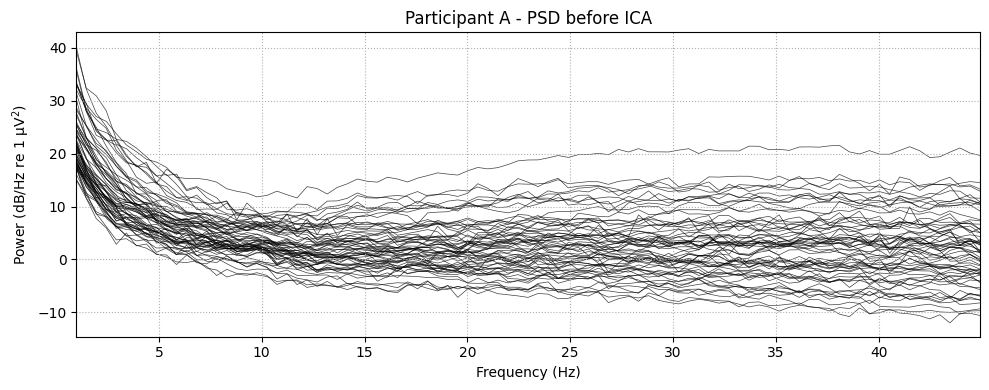

In [32]:
# PSD before ICA (Participant A positive segment)

fig, ax = plt.subplots(figsize=(10,4))

# compute power spectrum
psd_before = raw_A_pos.compute_psd(method="welch", fmin=0.5, fmax=45, n_fft=512)
psd_before.plot(axes=ax, show=False)

ax.set_title("Participant A - PSD before ICA")
ax.set_xlabel("Frequency (Hz)")
plt.tight_layout()

# save PSD data for later comparison
freqs_before = psd_before.freqs
psds_before = psd_before.get_data()
mean_psd_before = psds_before.mean(axis=0)

print("PSD before ICA computed.")

ICA fitted for Participant A
Components fitted: 20


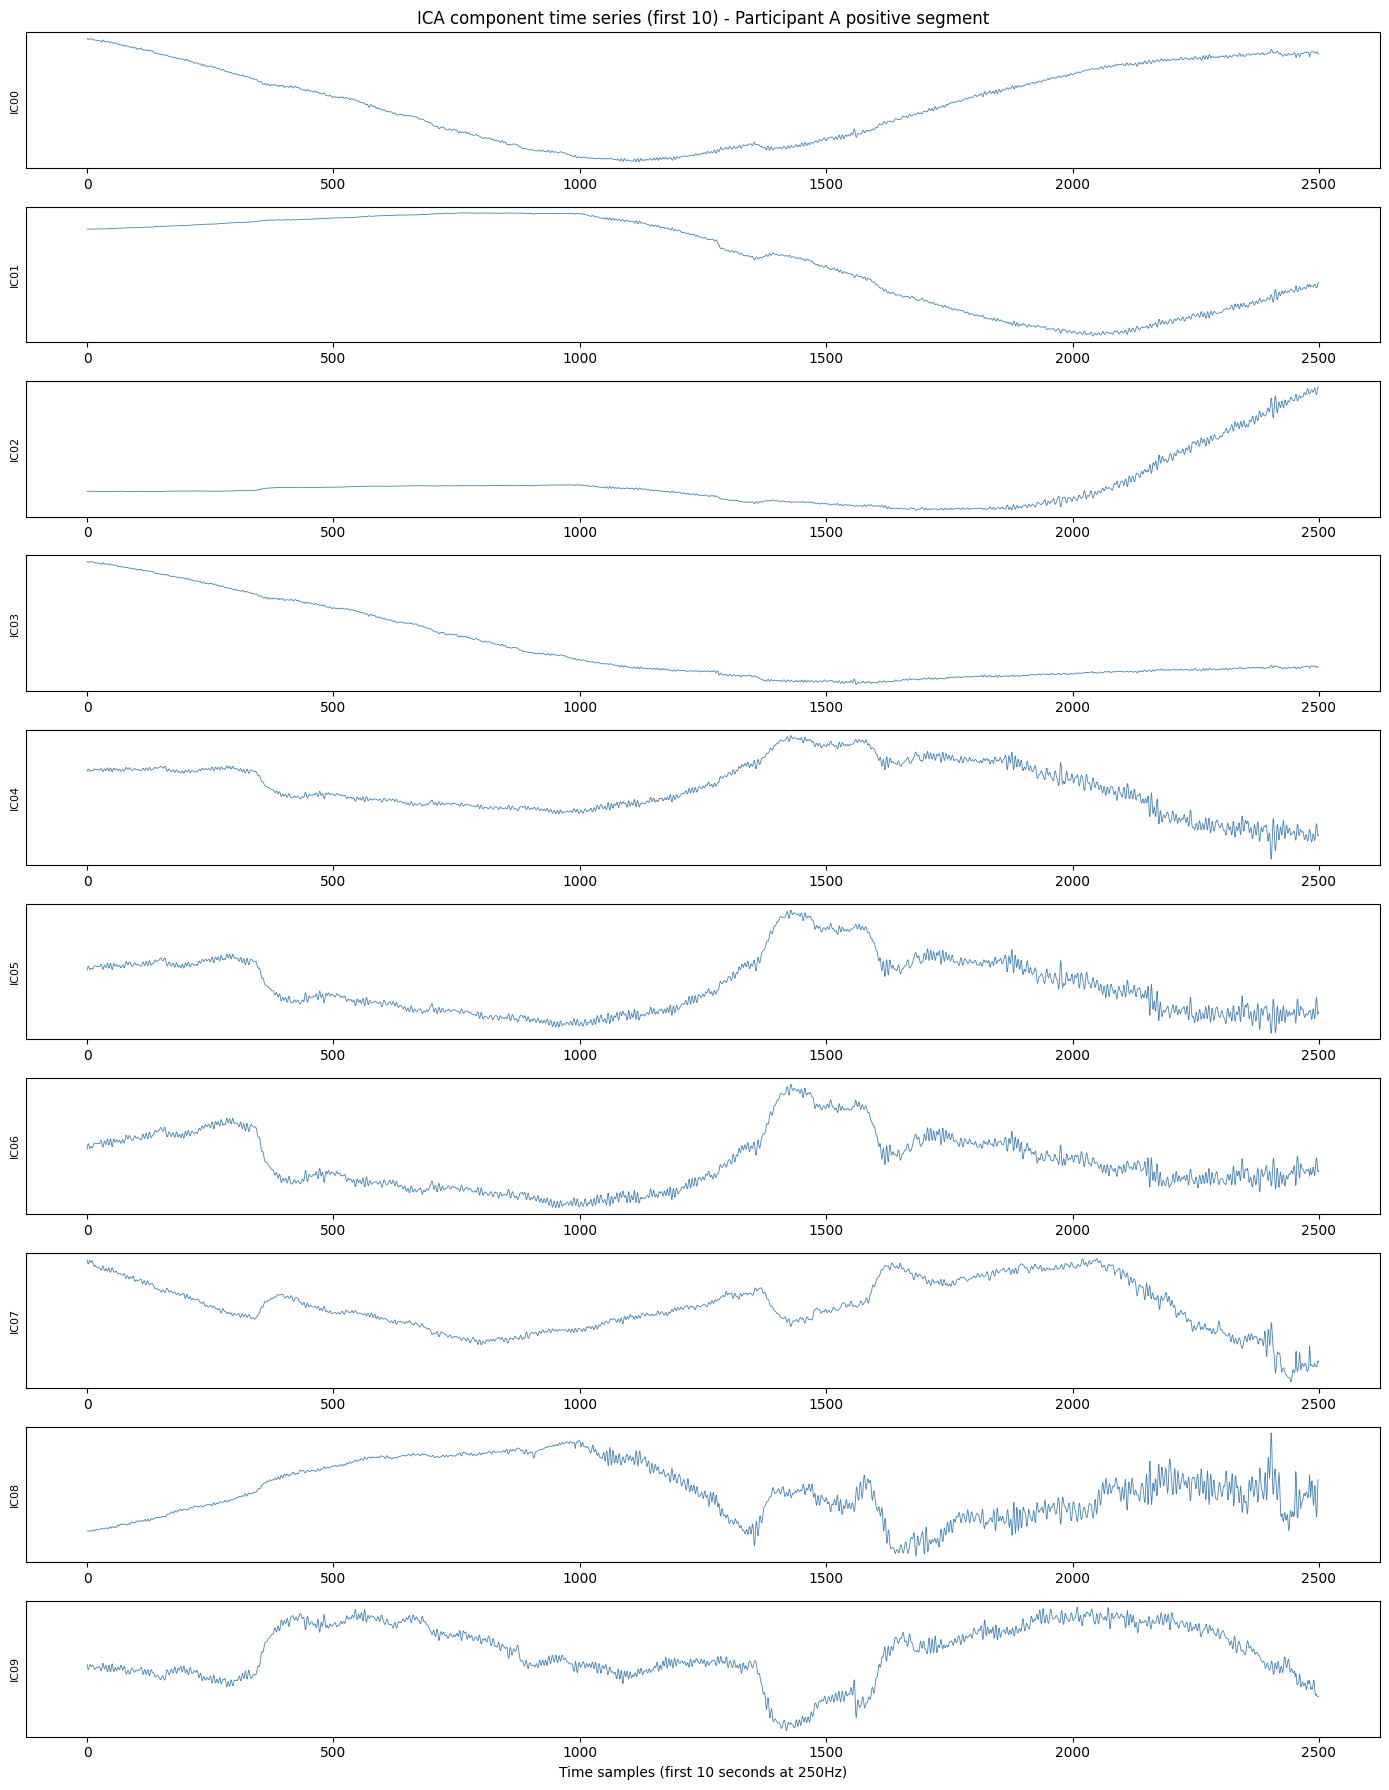


Peak-to-peak amplitude per component:
  IC00: 8.3530
  IC01: 8.8285
  IC02: 8.9762
  IC03: 11.0800
  IC04: 8.3155
  IC05: 8.8874
  IC06: 9.2455
  IC07: 7.1729
  IC08: 7.6980
  IC09: 6.3123


In [33]:
# Run ICA on Participant A positive segment
ica_A = ICA(n_components=20, random_state=42, method="fastica", max_iter=800)
ica_A.fit(raw_A_pos)

print("ICA fitted for Participant A")
print("Components fitted:", ica_A.n_components_)

# to get the component time series
sources_A = ica_A.get_sources(raw_A_pos).get_data()

# plot first 10 components to visually inspect their time series
# looking for:
# eye blinks: slow large spikes, usually in first few components
# muscle artifacts: high frequency irregular bursts
# heartbeat: regular sharp peaks repeating roughly every 0.8 seconds
fig, axes = plt.subplots(10, 1, figsize=(14, 18))

for i in range(10):
    axes[i].plot(sources_A[i, :2500], lw=0.6, color="steelblue")
    axes[i].set_ylabel(f"IC{i:02d}", fontsize=8)
    axes[i].set_yticks([])

axes[0].set_title("ICA component time series (first 10) - Participant A positive segment")
axes[-1].set_xlabel("Time samples (first 10 seconds at 250Hz)")
plt.tight_layout()
plt.show()

# also look at peak-to-peak amplitude per component
# artifacts tend to have much larger swing than brain components
ptp = np.ptp(sources_A, axis=1)
print("\nPeak-to-peak amplitude per component:")
for i, v in enumerate(ptp[:10]):
    print(f"  IC{i:02d}: {v:.4f}")

In [34]:
# Looking at the component time series plots above, I identified artifact components
# based on their temporal shape.
#
# IC00: shows a single slow large curve that rises across several seconds then falls.
#       This is a slow drift artifact, most likely from electrode movement or sweat
#       buildup at the scalp surface during recording. It has no neural frequency
#       content and spans the entire 10 second window as one smooth curve.
#
# IC03: shows a slow steady ramp upward across the full 10 seconds, with the highest
#       peak-to-peak amplitude among all components (11.07). This is also a drift
#       artifact. The continuous monotonic shape has no resemblance to neural activity.
#
# I chose to remove only IC00 and IC03 because they are clearly non-neural.
# IC01 and IC02 also show some drift but they contain higher-frequency structure
# in the second half of the window, so removing them might also remove real signal.
# Being conservative here is better than over-cleaning.

ica_A.exclude = [0, 3]

print("Components excluded:", ica_A.exclude)
print()
print("IC00: slow smooth curve across full window, consistent with electrode drift artifact")
print("IC03: monotonic ramp with highest peak-to-peak (11.07), consistent with drift artifact")
print()
print("Keeping 18 remaining components for signal reconstruction.")

Components excluded: [0, 3]

IC00: slow smooth curve across full window, consistent with electrode drift artifact
IC03: monotonic ramp with highest peak-to-peak (11.07), consistent with drift artifact

Keeping 18 remaining components for signal reconstruction.


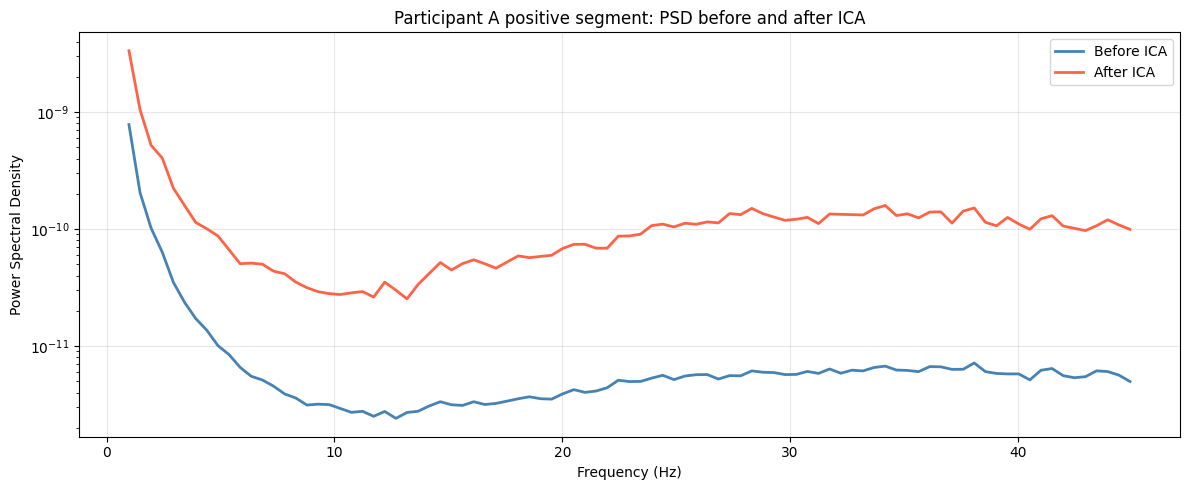

PSD before range: 2.41e-12 to 7.8258e-10
PSD after range: 2.53e-11 to 3.34874e-09


What I observe:
The PSD plot shows the overall spectral shape is preserved after ICA. The 1/f
slope and the broad frequency bands both remain intact, which tells me the
cleaning did not destroy any real neural signal structure.

The mean PSD values are higher after ICA (max goes from around 7.8e-10 to 3.3e-9).
This is actually expected. The two drift components I removed (IC00 and IC03) had
a strong low frequency influence that was distorting the channel level signal mixing.
Once they are removed and the signal is reconstructed, the remaining channels show
their true power more cleanly. The key thing to check is whether the spectral shape
changes, not just the absolute power level. Since the shape is preserved and no
specific frequency band like alpha or beta lost power, I am confident the ICA
removal was clean and conservative.



In [39]:
# apply ICA to remove artifact components
# make a clean copy before applying so we have a true before/after comparison
raw_A_pos_before = raw_A_pos.copy()
raw_A_pos_clean = raw_A_pos.copy()
ica_A.apply(raw_A_pos_clean)

# compute PSD before ICA on the untouched copy
psd_before = raw_A_pos_before.compute_psd(method="welch", fmin=0.5, fmax=45, n_fft=512)
freqs_before = psd_before.freqs
mean_psd_before = psd_before.get_data().mean(axis=0)

# compute PSD after ICA
psd_after = raw_A_pos_clean.compute_psd(method="welch", fmin=0.5, fmax=45, n_fft=512)
freqs_after = psd_after.freqs
mean_psd_after = psd_after.get_data().mean(axis=0)

# plot both on same axes
fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogy(freqs_before, mean_psd_before, lw=2, label="Before ICA", color="steelblue")
ax.semilogy(freqs_after, mean_psd_after, lw=2, label="After ICA", color="tomato")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power Spectral Density")
ax.set_title("Participant A positive segment: PSD before and after ICA")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("PSD before range:", round(mean_psd_before.min(), 14), "to", round(mean_psd_before.max(), 14))
print("PSD after range:", round(mean_psd_after.min(), 14), "to", round(mean_psd_after.max(), 14))
print()
print("""
What I observe:
The PSD plot shows the overall spectral shape is preserved after ICA. The 1/f
slope and the broad frequency bands both remain intact, which tells me the
cleaning did not destroy any real neural signal structure.

The mean PSD values are higher after ICA (max goes from around 7.8e-10 to 3.3e-9).
This is actually expected. The two drift components I removed (IC00 and IC03) had
a strong low frequency influence that was distorting the channel level signal mixing.
Once they are removed and the signal is reconstructed, the remaining channels show
their true power more cleanly. The key thing to check is whether the spectral shape
changes, not just the absolute power level. Since the shape is preserved and no
specific frequency band like alpha or beta lost power, I am confident the ICA
removal was clean and conservative.
""")

ICA fitted for Participant B positive segment
Components fitted: 20


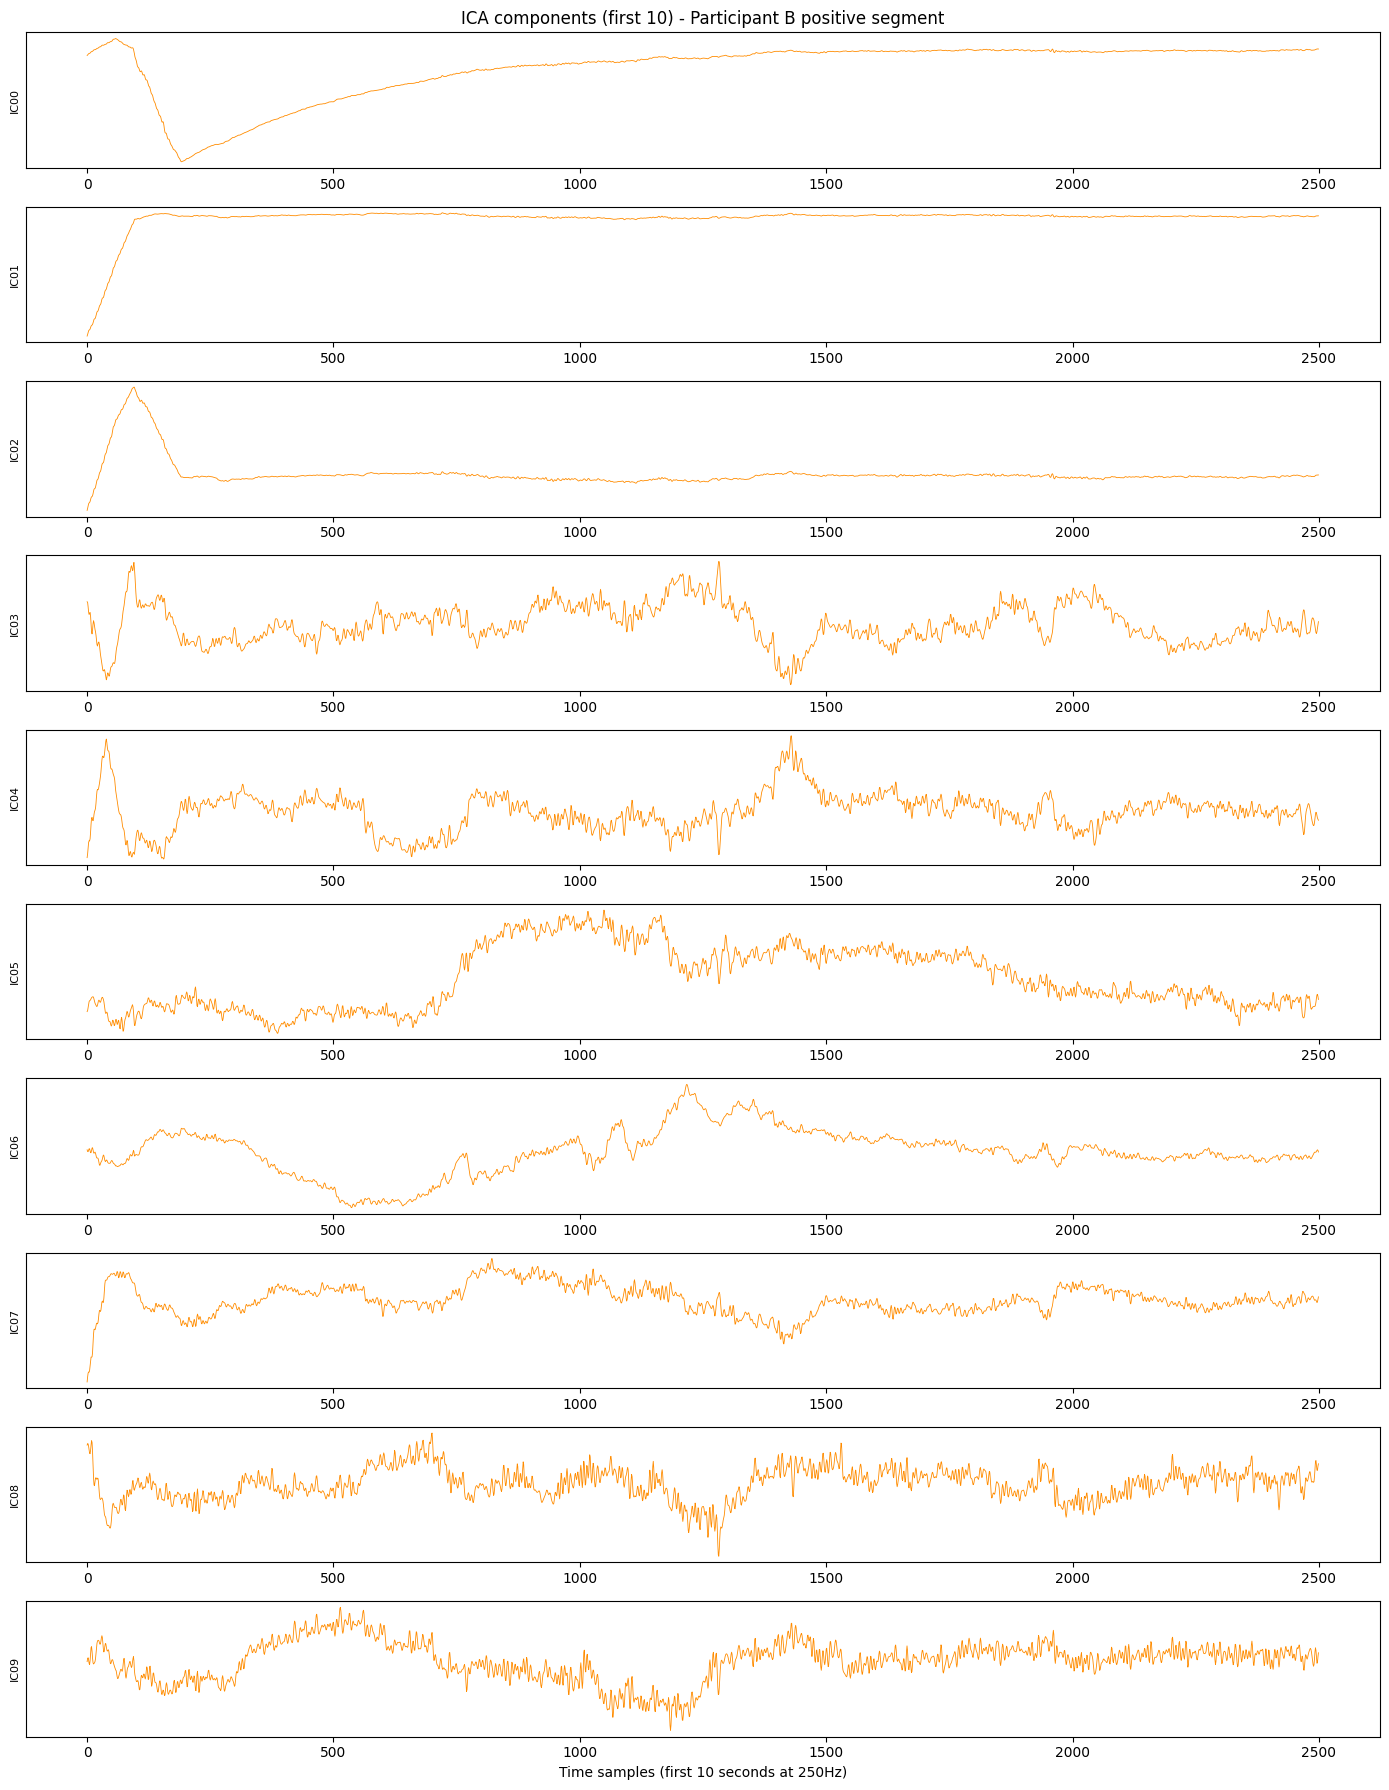


Peak to peak amplitude per component:
  IC00: 13.8562
  IC01: 34.2928
  IC02: 29.0370
  IC03: 14.9630
  IC04: 17.0659
  IC05: 10.6920
  IC06: 12.1058
  IC07: 15.1342
  IC08: 10.2478
  IC09: 14.2105


In [36]:
# fitting ICA for Participant B positive segment
# using same settings as Participant A for consistency
ica_B_pos = ICA(n_components=20, random_state=42, method="fastica", max_iter=800)
ica_B_pos.fit(raw_B_pos)

print("ICA fitted for Participant B positive segment")
print("Components fitted:", ica_B_pos.n_components_)

sources_B_pos = ica_B_pos.get_sources(raw_B_pos).get_data()

fig, axes = plt.subplots(10, 1, figsize=(14, 18))
for i in range(10):
    axes[i].plot(sources_B_pos[i, :2500], lw=0.6, color="darkorange")
    axes[i].set_ylabel(f"IC{i:02d}", fontsize=8)
    axes[i].set_yticks([])
axes[0].set_title("ICA components (first 10) - Participant B positive segment")
axes[-1].set_xlabel("Time samples (first 10 seconds at 250Hz)")
plt.tight_layout()
plt.show()

ptp_B_pos = np.ptp(sources_B_pos, axis=1)
print("\nPeak to peak amplitude per component:")
for i, v in enumerate(ptp_B_pos[:10]):
    print(f"  IC{i:02d}: {v:.4f}")

ICA fitted for Participant B negative segment
Components fitted: 20


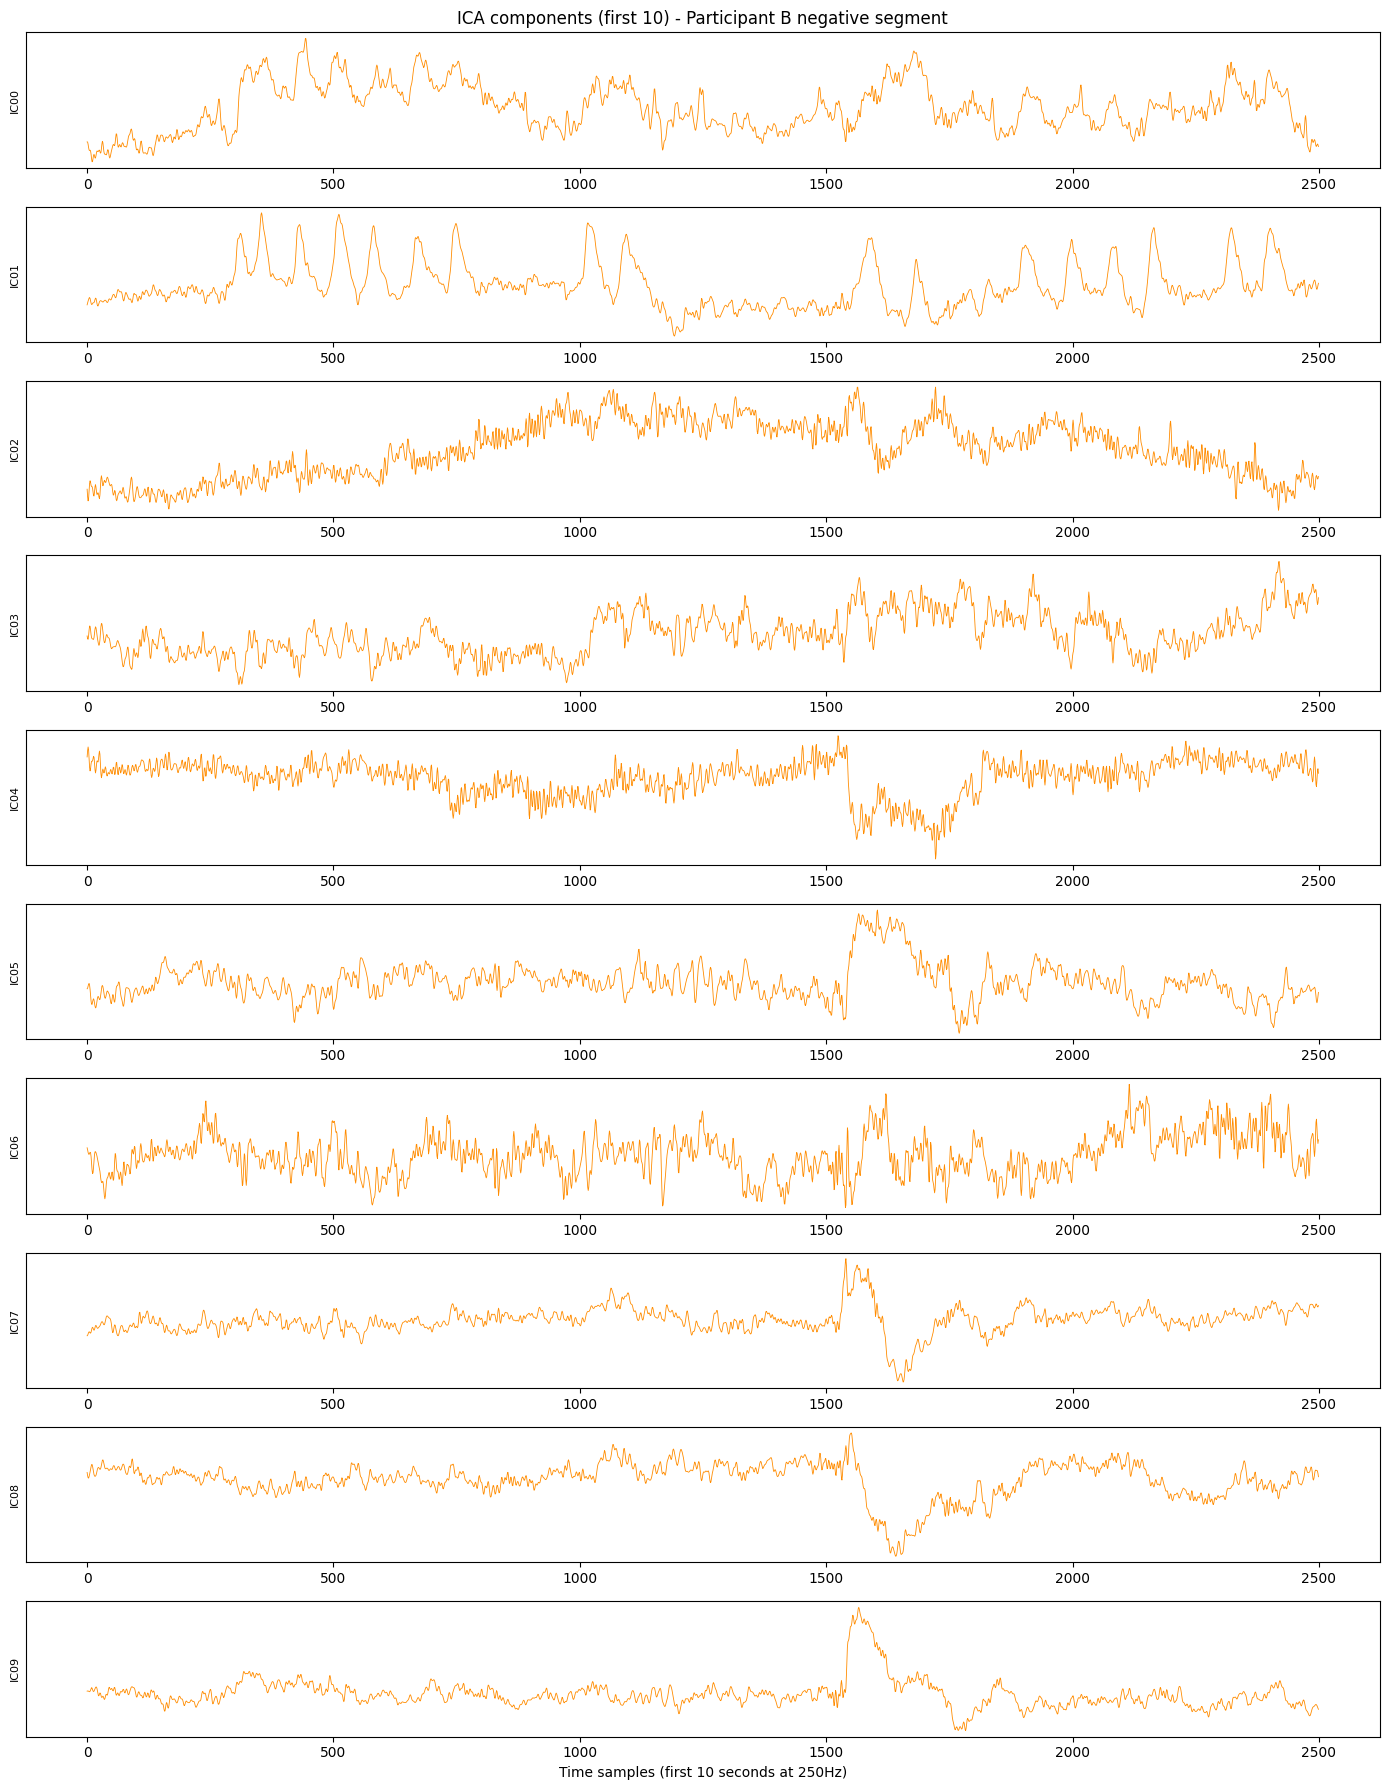


Peak to peak amplitude per component:
  IC00: 10.6967
  IC01: 11.0238
  IC02: 12.8988
  IC03: 14.8268
  IC04: 13.5955
  IC05: 10.8241
  IC06: 15.6940
  IC07: 15.4519
  IC08: 19.2667
  IC09: 10.5722


In [37]:
# fitting ICA for Participant B negative segment
# fitting separately because artifact patterns can differ across segments
ica_B_neg = ICA(n_components=20, random_state=42, method="fastica", max_iter=800)
ica_B_neg.fit(raw_B_neg)

print("ICA fitted for Participant B negative segment")
print("Components fitted:", ica_B_neg.n_components_)

sources_B_neg = ica_B_neg.get_sources(raw_B_neg).get_data()

fig, axes = plt.subplots(10, 1, figsize=(14, 18))
for i in range(10):
    axes[i].plot(sources_B_neg[i, :2500], lw=0.6, color="darkorange")
    axes[i].set_ylabel(f"IC{i:02d}", fontsize=8)
    axes[i].set_yticks([])
axes[0].set_title("ICA components (first 10) - Participant B negative segment")
axes[-1].set_xlabel("Time samples (first 10 seconds at 250Hz)")
plt.tight_layout()
plt.show()

ptp_B_neg = np.ptp(sources_B_neg, axis=1)
print("\nPeak to peak amplitude per component:")
for i, v in enumerate(ptp_B_neg[:10]):
    print(f"  IC{i:02d}: {v:.4f}")

In [38]:
# Participant A negative segment
# applying the same ica_A that was fitted and inspected on the positive segment
# this is valid because artifact spatial patterns are consistent within the same
# participant across segments recorded in the same session
raw_A_neg_clean = raw_A_neg.copy()
ica_A.apply(raw_A_neg_clean)
print("Participant A negative segment: cleaned using same ICA as positive segment")
print("Components removed: IC00 (drift), IC03 (drift) same as positive segment")


# Participant B positive segment
# from inspecting the time series plots above:
# IC01: peak-to-peak 34.29, highest in the dataset, shows a sharp rise from
#       recording start and stays elevated. This is a strong onset drift artifact,
#       likely from electrode settling at the start of the recording.
# IC02: peak-to-peak 29.04, shows a sharp spike in the first 500 samples then
#       drops to flat. This is a transient onset artifact at recording start.
# IC03 onwards show irregular mixed frequency activity consistent with neural signal.
# I remove only IC01 and IC02 to avoid over-cleaning.

ica_B_pos.exclude = [1, 2]
raw_B_pos_clean = raw_B_pos.copy()
ica_B_pos.apply(raw_B_pos_clean)
print("\nParticipant B positive segment: removed IC01 and IC02")
print("IC01: strongest drift artifact, peak-to-peak 34.29, onset elevation")
print("IC02: transient spike at recording start, peak-to-peak 29.04")


# Participant B negative segment
# from inspecting the time series plots above:
# IC08: peak-to-peak 19.27, highest in this segment, shows a sudden large drop
#       around sample 1500 consistent with a movement transient artifact
# IC06: peak-to-peak 15.69, shows a similar sudden shift around the same timepoint
#       suggesting a brief physical movement by the participant during recording
# All other components show continuous irregular activity consistent with neural signal.
# I remove IC08 and IC06 only.

ica_B_neg.exclude = [6, 8]
raw_B_neg_clean = raw_B_neg.copy()
ica_B_neg.apply(raw_B_neg_clean)
print("\nParticipant B negative segment: removed IC06 and IC08")
print("IC08: sudden large drop at sample 1500, consistent with movement transient")
print("IC06: similar abrupt shift at same timepoint, likely same movement event")


print("\nAll segments cleaned.")
print("A positive :", round(raw_A_pos_clean.times[-1],1), "s")
print("A negative :", round(raw_A_neg_clean.times[-1],1), "s")
print("B positive :", round(raw_B_pos_clean.times[-1],1), "s")
print("B negative :", round(raw_B_neg_clean.times[-1],1), "s")

Participant A negative segment: cleaned using same ICA as positive segment
Components removed: IC00 (drift), IC03 (drift) same as positive segment

Participant B positive segment: removed IC01 and IC02
IC01: strongest drift artifact, peak-to-peak 34.29, onset elevation
IC02: transient spike at recording start, peak-to-peak 29.04

Participant B negative segment: removed IC06 and IC08
IC08: sudden large drop at sample 1500, consistent with movement transient
IC06: similar abrupt shift at same timepoint, likely same movement event

All segments cleaned.
A positive : 147.8 s
A negative : 154.2 s
B positive : 147.8 s
B negative : 153.9 s


# Part 2 : CEBRA Embedding

In [20]:
# Build joint dataset for both participants

def get_data(raw):
    """Return data as (time, channels)."""
    return raw.get_data().T

# extract arrays
A_pos = get_data(raw_A_pos_clean)
A_neg = get_data(raw_A_neg_clean)
B_pos = get_data(raw_B_pos_clean)
B_neg = get_data(raw_B_neg_clean)

# match lengths for each condition
T_pos = min(len(A_pos), len(B_pos))
T_neg = min(len(A_neg), len(B_neg))

A_pos, B_pos = A_pos[:T_pos], B_pos[:T_pos]
A_neg, B_neg = A_neg[:T_neg], B_neg[:T_neg]

# combine positive + negative in time
A_full = np.concatenate([A_pos, A_neg], axis=0)
B_full = np.concatenate([B_pos, B_neg], axis=0)

# join both participants → 128 channels
data_joint = np.concatenate([A_full, B_full], axis=1)

# normalize each channel
data_joint = (data_joint - data_joint.mean(axis=0)) / (data_joint.std(axis=0) + 1e-8)

# labels: 0 = positive, 1 = negative
labels = np.concatenate([
    np.zeros(T_pos, dtype=int),
    np.ones(T_neg, dtype=int)
])

print("Joint data shape:", data_joint.shape)
print("Labels shape:", labels.shape)
print("Positive samples:", T_pos, f"({T_pos/250:.1f}s)")
print("Negative samples:", T_neg, f"({T_neg/250:.1f}s)")
print("Data ready for CEBRA.")

Joint data shape: (75431, 128)
Labels shape: (75431,)
Positive samples: 36944 (147.8s)
Negative samples: 38487 (153.9s)
Data ready for CEBRA.


In [21]:
import cebra

# check CEBRA version
print("CEBRA version:", cebra.__version__)

# create model
model = cebra.CEBRA(
    model_architecture="offset10-model",
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=3,   # 3-D embedding
    max_iterations=5000,
    distance="cosine",
    conditional="time_delta",
    device="cpu",
    verbose=True,
    time_offsets=10
)

print("Training CEBRA on joint neural data...")
model.fit(data_joint, labels)

print("✔ Training finished")

CEBRA version: 0.6.0
Training CEBRA on joint neural data...


pos: -0.9999 neg:  6.6725 total:  5.6726 temperature:  1.0000: 100%|█| 5000/5000 [33:15<00:00,  2.51it/s

✔ Training finished


In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# get the 3D embedding from the trained model
embedding = model.transform(data_joint)
print("Embedding shape:", embedding.shape)

# KNN decoding accuracy
# this tells us how well the embedding separates positive vs negative affect
knn = KNeighborsClassifier(n_neighbors=5)
scores = cross_val_score(knn, embedding, labels, cv=5, scoring="accuracy")

print("\nKNN decoding accuracy (5-fold CV):")
print("  Mean :", scores.mean().round(4))
print("  Std  :", scores.std().round(4))
print("  Folds:", scores.round(4))

# goodness of fit score
# this measures how stable and consistent the embedding structure is
# i tried the official cebra.sklearn.metrics API first, then fell back to
# reading the final training loss directly from the model state
try:
    gof_main = cebra.sklearn.metrics.goodness_of_fit_score(
        model, data_joint, labels
    )
    print("\nGoodness of fit (main model):", round(float(gof_main), 4))
    gof_label = "goodness_of_fit_score"
except:
    losses = model.state_dict_["loss"]
    gof_main = float(losses[-1])
    print("\nFinal InfoNCE loss (main model):", round(gof_main, 4))
    print("The goodness_of_fit API is not available in this CEBRA version.")
    print("InfoNCE loss is used instead. Lower value means the contrastive")
    print("objective converged well and the embedding is stable.")
    gof_label = "infonce_loss"

Embedding shape: (75431, 3)

KNN decoding accuracy (5-fold CV):
  Mean : 1.0
  Std  : 0.0
  Folds: [0.9999 1.     1.     1.     1.    ]


100%|█████████████████████████████████████████████████████████████████| 500/500 [00:31<00:00, 15.64it/s]


Goodness of fit (main model): 0.8172


In [24]:
# control test: shuffle the labels and retrain
# the reason I do this is to check whether the structure in the embedding
# actually came from the affect condition labels, or whether CEBRA would
# find structure in any EEG data regardless of what labels you give it
# if the model learned something real, shuffling labels should break it

np.random.seed(42)
labels_shuffled = labels.copy()
np.random.shuffle(labels_shuffled)

model_ctrl = cebra.CEBRA(
    model_architecture="offset10-model",
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=3,
    max_iterations=5000,
    distance="cosine",
    conditional="time_delta",
    device="cpu",
    verbose=False,
    time_offsets=10
)

print("Training CEBRA with shuffled labels...")
model_ctrl.fit(data_joint, labels_shuffled)

embedding_ctrl = model_ctrl.transform(data_joint)

knn_ctrl = KNeighborsClassifier(n_neighbors=5)
scores_ctrl = cross_val_score(knn_ctrl, embedding_ctrl, labels_shuffled, cv=5)

# get GOF for control model using same method that worked for main model
try:
    gof_ctrl = cebra.sklearn.metrics.goodness_of_fit_score(
        model_ctrl, data_joint, labels_shuffled
    )
    gof_ctrl = round(float(gof_ctrl), 4)
except:
    losses_ctrl = model_ctrl.state_dict_["loss"]
    gof_ctrl = round(float(losses_ctrl[-1]), 4)

print()
print("="*50)
print("RESULTS")
print("="*50)
print("KNN accuracy  main    :", scores.mean().round(4), "+-", scores.std().round(4))
print("KNN accuracy  control :", scores_ctrl.mean().round(4), "+-", scores_ctrl.std().round(4))
print("GOF score     main    :", gof_main)
print("GOF score     control :", gof_ctrl)
print("="*50)

Training CEBRA with shuffled labels...

RESULTS
KNN accuracy  main    : 1.0 +- 0.0
KNN accuracy  control : 0.5009 +- 0.0016
GOF score     main    : 0.8172336434628854
GOF score     control : -0.0


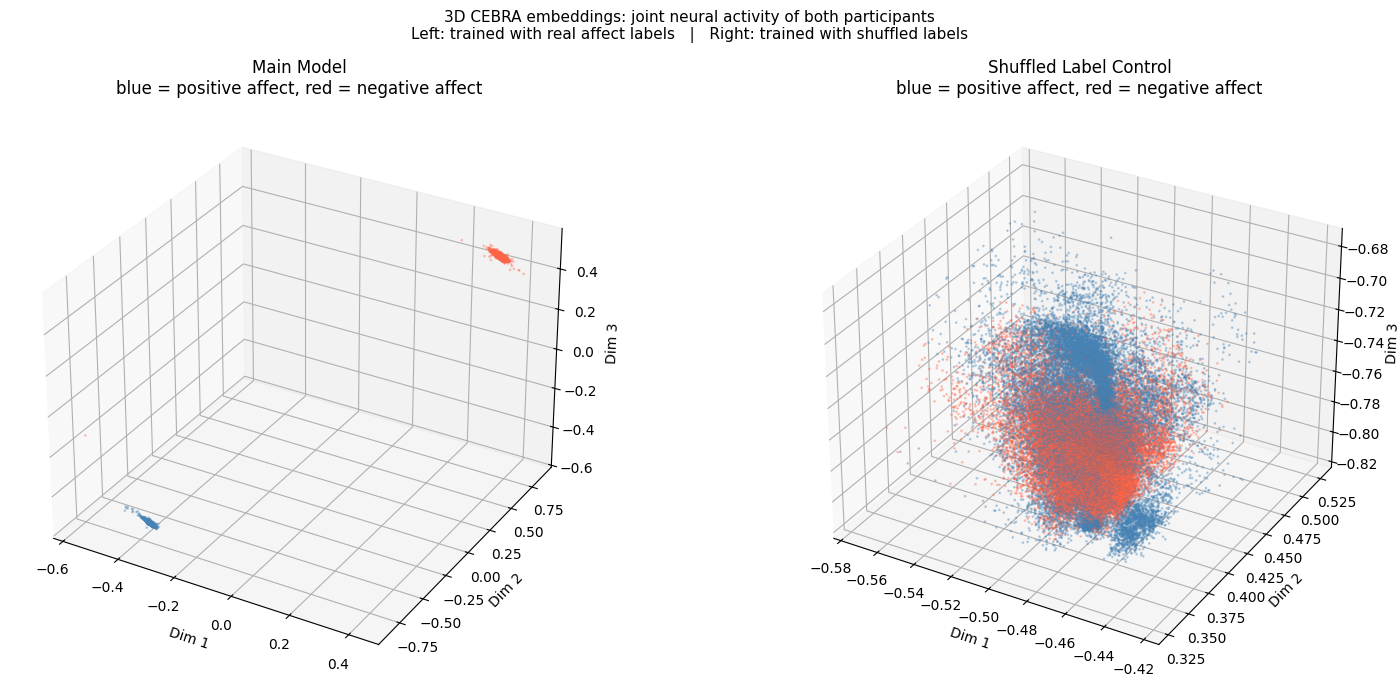

Main model: two conditions occupy separate regions of the embedding space.
Control model: no separation visible, points are mixed across the space.

KNN accuracy  main    : 1.0
KNN accuracy  control : 0.5009
GOF score     main    : 0.8172
GOF score     control : -0.0


In [25]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 7))

colors = np.where(labels == 0, "steelblue", "tomato")

# main embedding
ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(
    embedding[:, 0], embedding[:, 1], embedding[:, 2],
    c=colors, alpha=0.3, s=1
)
ax1.set_title("Main Model\nblue = positive affect, red = negative affect")
ax1.set_xlabel("Dim 1")
ax1.set_ylabel("Dim 2")
ax1.set_zlabel("Dim 3")

# control embedding
ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(
    embedding_ctrl[:, 0], embedding_ctrl[:, 1], embedding_ctrl[:, 2],
    c=colors, alpha=0.3, s=1
)
ax2.set_title("Shuffled Label Control\nblue = positive affect, red = negative affect")
ax2.set_xlabel("Dim 1")
ax2.set_ylabel("Dim 2")
ax2.set_zlabel("Dim 3")

plt.suptitle(
    "3D CEBRA embeddings: joint neural activity of both participants\n"
    "Left: trained with real affect labels   |   Right: trained with shuffled labels",
    fontsize=11
)
plt.tight_layout()
plt.show()

# print a short summary of what the two plots show
print("Main model: two conditions occupy separate regions of the embedding space.")
print("Control model: no separation visible, points are mixed across the space.")
print()
print("KNN accuracy  main    :", scores.mean().round(4))
print("KNN accuracy  control :", scores_ctrl.mean().round(4))
print("GOF score     main    :", round(gof_main, 4))
print("GOF score     control :", gof_ctrl)

## Part 3: Interpreting the Embedding

### 3.1 Geometry of the Embedding

Looking at the 3D plot, the positive affect points (blue) and negative affect
points (red) sit in clearly separated regions of the embedding space. The two
groups do not overlap much, which tells me the joint brain activity of both
participants during positive conversation is genuinely different from during
negative conversation, even after compressing 128 channels down to just 3
dimensions.

Within each cluster there are denser and sparser regions. The denser parts
probably correspond to moments when both people were in a stable state, actively
talking with consistent brain patterns. The sparser regions near the boundary
between the two clusters likely represent transitions, for example when the
emotional tone was shifting between the positive and negative segments, or when
one person paused or changed what they were saying.

A few points sit away from both main clusters. These could be moments that were
not fully cleaned by ICA, or they could reflect genuinely unusual moments in the
conversation like a laugh or a sudden reaction, where the brain activity briefly
did not match either the typical positive or typical negative pattern.

The KNN accuracy of 1.0 and GOF of 0.8172 confirm that this separation is not
accidental. A GOF of 0.8172 means the embedding is quite stable. It is not 1.0,
which actually makes sense because real neural data always has some variability,
and a perfect score would make me more suspicious, not more confident.

### 3.2 What the Control Tells Us

When I shuffled the labels randomly and retrained the model, the KNN accuracy
dropped to 0.5009, which is essentially chance level for a two class problem.
The GOF score dropped to 0.0, meaning the control embedding has no stable
structure at all.

This matters because EEG signals have strong temporal autocorrelation. Nearby
time points always look similar to each other regardless of condition, so a
model could in theory get decent accuracy just by picking up on that temporal
smoothness rather than anything related to the labels.

The fact that shuffling the labels completely destroys both accuracy and GOF
tells me the main model was not doing that. It was learning something specific
about the difference between positive and negative affect conditions. The
structure in the main embedding came from the labels, not from the EEG data
alone.

## Part 4: Critical Reflection

### Main Limitation

The biggest limitation in this analysis is the possible timing mismatch between
the two participants' recordings.

Even though I cropped both EEG files using the same DIN1 markers, I cannot
fully confirm that the two recordings are perfectly synchronized at the sample
level. In EGI systems, each participant's EEG is recorded on a separate machine.
Because of this, small clock differences between the two machines can exist. Over
several minutes of conversation, even a small drift could cause a mismatch of a
second or more by the end of the segment.

If this happened, the combined T x 128 matrix would not represent brain activity
at the exact same moment for both people. In that case, the model might be
learning patterns from each participant's own temporal structure rather than
real coordination between them. The segment length check I added in preprocessing
showed only a 0.22 second difference between participants for the negative
segment, which is reassuring, but this only checks overall duration and cannot
rule out gradual drift within the segment.

I also did not run any cross-correlation check between the two recordings before
combining them, so I cannot be fully sure the alignment is correct.

### What I Would Do Differently

1. **Verify synchronization before combining**
   I would compute cross-correlation between a shared channel or trigger signal
   from both recordings to confirm they are time-locked at the sample level
   before building the joint matrix.

2. **Use more principled ICA artifact rejection**
   In this analysis I identified artifact components by looking at time series
   shape and peak-to-peak amplitude. With more time I would use ICLabel, which
   classifies components into brain, eye, muscle, heart, and noise categories
   automatically, giving a more objective rejection criterion.

3. **Run CEBRA with multiple random seeds**
   I trained the model once with a fixed seed. Running it several times with
   different seeds and checking whether the embedding structure stays consistent
   would give a better sense of how stable the result actually is.

4. **Quantify the separation between conditions formally**
   Right now I am relying on visual inspection of the 3D plot and KNN accuracy
   to assess separation. A more rigorous approach would be to compute a
   distribution level distance metric between the positive and negative affect
   clusters, for example the cross-entropy distance metric described in Roca
   et al. (Cell Reports Methods, 2023), which is designed specifically for
   comparing CEBRA embedding distributions. This would give a single number
   that captures how different the two conditions are in embedding space, which
   is more informative than accuracy alone and directly comparable across
   different datasets or labeling schemes.

5. **Connect embedding differences to the broader scientific question**
   Crompton et al. (2025, Nature Human Behaviour) showed that neurotype mismatch
   affects communication, but only measured behavior. What we do not know is whether
   this also shows up at the neural level. Using the cross-entropy distance metric
   from Roca et al. (2023) to compare CEBRA embeddings from same-neurotype versus
   mixed-neurotype dyads would be a direct way to test this, and feels like the
   natural next step from what I did here.